# Data Curation with values

## Setup

In [327]:
!git clone https://huggingface.co/spaces/uc-ctds/ai_assisted_data_curation_toolkit

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


fatal: destination path 'ai_assisted_data_curation_toolkit' already exists and is not an empty directory.


In [328]:
# sqlite fix for chroma
import pysqlite3 as sqlite3
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

In [329]:
import chromadb
import os
import json
import math
import pandas as pd
import numpy as np
from types import SimpleNamespace
from itertools import chain
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu


In [330]:
from ai_harmonization.simple_data_model import SimpleDataModel

## Use a Harmonization Approach with values to get Suggestions

### Get Input Data

- A `target data model` you want to harmonize to
- We will use a test BIOLINCC study, where variables have values added
- The `target data model` example is the **NHLBI BioData Catalyst Gen3 Data Dictionary**


In [331]:
target_file = "../data/example_target_model_BDC.json"

with open(target_file, "r") as f:
    input_target_model = json.load(f)

input_target_model = SimpleDataModel.get_from_unknown_json_format(
    json.dumps(input_target_model)
)

In [332]:
print("Target Model")
input_target_model.get_property_df()

Target Model


,node_name,property_name,property_description,property_type,additional_metadata
0,acknowledgement,acknowledgee,The indvidiual or group being acknowledged by ...,string,None
1,acknowledgement,created_datetime,,,None
2,acknowledgement,id,,string,None
3,acknowledgement,project_id,,string,None
4,acknowledgement,projects,,,None
...,...,...,...,...,...
823,submitted_unaligned_reads,read_groups,,,None
824,submitted_unaligned_reads,state,,,None
825,submitted_unaligned_reads,submitter_id,A project-specific identifier for a node. This...,[string],None
826,submitted_unaligned_reads,type,,string,None


In [333]:
target_df = input_target_model.get_property_df()

In [334]:
def format_node_name_property_name_prop_description(row):
    return f"{row['node_name']}.{row['property_name']} ({row['property_type']}): {row['property_description']}"

In [335]:
target_df['node_name_prop_name_type_and_desc'] = target_df.apply(format_node_name_property_name_prop_description, axis=1)

In [336]:
target_df['node_name_prop_name_type_and_desc'].iloc[0]

'acknowledgement.acknowledgee (string): The indvidiual or group being acknowledged by the project.'

In [337]:
target_df.head(n=3)

,node_name,property_name,property_description,property_type,additional_metadata,node_name_prop_name_type_and_desc
0,acknowledgement,acknowledgee,The indvidiual or group being acknowledged by ...,string,None,acknowledgement.acknowledgee (string): The ind...
1,acknowledgement,created_datetime,,,None,acknowledgement.created_datetime ():
2,acknowledgement,id,,string,None,acknowledgement.id (string):


***Push to a collection***
- embed prop_name_and_description using bge

In [338]:
from FlagEmbedding import FlagModel
model = FlagModel('BAAI/bge-large-en-v1.5', use_fp16=True)
# custom embedding model
# model = FlagModel('uc-ctds/bge-large-en-v1.5-bio-mapping', use_fp16=True)
models = {
    "node_name_prop_name_type_and_desc": FlagModel('BAAI/bge-large-en-v1.5')
}

In [339]:
embeddings = {
    'node_name_prop_name_type_and_desc': models['node_name_prop_name_type_and_desc'].encode(target_df['node_name_prop_name_type_and_desc'].tolist())
}

pre tokenize: 100%|██████████| 2/2 [00:00<00:00, 91.06it/s]
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
pre tokenize: 100%|██████████| 2/2 [00:00<00:00, 77.76it/s]
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Chunks: 100%|██████████| 2/2 [00:04<00:00,  2.13s/it]


In [340]:
len(embeddings['node_name_prop_name_type_and_desc'])

828

In [341]:
client = chromadb.Client()

In [342]:
try:
    # delete collection if already exists
    client.delete_collection(name='prop_name_desc')
except Exception:
    print('collection does not exist, do nothing')

In [343]:
collection = client.create_collection("prop_name_desc", metadata={"hnsw:space": "cosine"})

In [344]:
batch_size = 5000
for i in range(0, target_df.shape[0], batch_size):
    print(f'adding records to collection, from {i} to {i+batch_size}')
    # just supply a list of embeddings and metadata to chroma
    # see https://docs.trychroma.com/docs/collections/add-data
    collection.add(
        embeddings=embeddings['node_name_prop_name_type_and_desc'][i:i+batch_size].tolist(),
        ids=target_df['node_name_prop_name_type_and_desc'][i:i+batch_size].tolist()
        #metadatas=target_df.to_dict("records")[i:i+batch_size]
    )

adding records to collection, from 0 to 5000


In [345]:
def get_combined_query_emb(query_var_name, query_var_desc):
    # init to 0
    query_var_name_desc = ' : '.join([query_var_name, query_var_desc])
    query_combined_emb = models['node_name_prop_name_type_and_desc'].encode(query_var_name_desc)
    return query_combined_emb

In [346]:
def get_top_k(query_combined_emb, k):
    results = collection.query(
        query_embeddings=query_combined_emb,
        n_results=k
    )
    return results

In [347]:
from types import SimpleNamespace
def init_query_vars():
    query_var_name = ''
    query_var_desc = ''
    query_var_type = ''
    query_var_val_cat = ''
    query_var_val_num = ''
    return SimpleNamespace(
        query_var_name=query_var_name,
        query_var_desc=query_var_desc,
        query_var_type=query_var_type,
        query_var_val_cat=query_var_val_cat,
        query_var_val_num=query_var_val_num
)

In [348]:
def return_top_k_results(row, k):
    query_var_name = str(row['source_name'])
    query_var_desc = str(row['source_desc'])
    query_vars = init_query_vars()
    query_vars.query_var_name = query_var_name
    #print(f'name,desc: {query_var_name}, {query_var_desc}')
    query_combined_emb = get_combined_query_emb(query_vars.query_var_name, query_vars.query_var_desc)
    results = get_top_k(query_combined_emb, k)
    return results

In [349]:
def format_results(results):
    formatted_results_df = pd.DataFrame({
        'ids': results['ids'][0],
        'distances': results['distances'][0]
    })
    formatted_results_df.sort_values(by='distances', ascending=True, inplace=True)
    formatted_results_df['names'] = formatted_results_df['ids'].apply(lambda x: x.split(' ')[0])
    return pd.Series([
        formatted_results_df['ids'].to_list(),
        formatted_results_df['distances'].to_list(),
        formatted_results_df['names'].to_list()
    ])

In [350]:
# test on phs003738.source.csv
def process_benchmark(benchmark_name):
    print(f'processing {benchmark_name}')
    df = pd.read_csv(benchmark_name, index_col=0, sep='\t')
    df = df.dropna(subset=['source_name', 'source_desc', 'source_values'])
    # embed query variables -- var name, var desc and return top_k
    # by searching CDE embeddings
    # print('embedding and retrieving data')
    top_k_list = [1, 5, 10]
    for k in top_k_list:
        col_name = f'top_{k}_results'
        # print(f'returning results for top {k}')
        df[col_name] = df.apply(lambda x: return_top_k_results(x, k=k), axis=1)
        # format results
        output_cols = f'top_{k}_ids,top_{k}_distances,top_{k}_names'.split(',')
        df[output_cols] = df[col_name].apply(
            lambda x: format_results(x)
        )
    print('returning top k results')
    return df


In [351]:
def calculate_acc(truth, pred, k):
  # print(f'calculating accuracy, k: {k}')
  correct = 0
  # print(f'truth: {truth}')
  # print(f'pred: {pred}')
  for t, p_list_of_names in zip(truth, pred):
      if t in p_list_of_names:
          correct += 1
  return correct / len(truth)

In [352]:
def calculate_acc_per_row(truth, pred):
    correct = 0
    if truth in pred:
        correct += 1
    return correct / len(truth)

In [353]:
def run_evals(df, benchmark_name, embedding_model):
    # print('calculating metrics')
    evals = {}
    row_index = []
    top_k_list = [1, 5, 10]
    for k in top_k_list:
        evals[f'accuracy_{k}'] = []
    for d in [df]:
        row_index.append(f'{benchmark_name}_{d.shape[0]}_{embedding_model}')
        for k in top_k_list:
            col_name = f'top_{k}_names'
            top_k_names_list = d[col_name].to_list()
            truth_list = d['target_name'].to_list()
            accuracy = calculate_acc(truth_list, top_k_names_list, k)
            evals[f'accuracy_{k}'].append(accuracy)

    # print('returning metrics')
    return pd.DataFrame(evals, index=row_index)

In [354]:
def run_evals_per_row(row, k):
    col_name = f'top_{k}_names'
    top_k_names_list = row[col_name]
    truth = row['target_name']
    is_match = truth in top_k_names_list
    return is_match

In [355]:
def get_metrics_per_row(df):
    top_k_list = [5]
    for k in top_k_list:
        output_cols = f'is_match_in_top_{k}_name_desc'
        df[output_cols] = df.apply(lambda x: run_evals_per_row(x, k), axis=1)
    return df

### per row eval

In [356]:
benchmark_name = '../data/phs003738.source.csv'
embedding_model = 'bge'
df = process_benchmark(benchmark_name=benchmark_name)
metrics_per_row = get_metrics_per_row(df)

processing ../data/phs003738.source.csv


You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


returning top k results


In [357]:
df.columns

Index(['source_name', 'source_desc', 'source_values', 'source_type',
       'target_name', 'target_values', 'top_1_results', 'top_1_ids',
       'top_1_distances', 'top_1_names', 'top_5_results', 'top_5_ids',
       'top_5_distances', 'top_5_names', 'top_10_results', 'top_10_ids',
       'top_10_distances', 'top_10_names', 'is_match_in_top_5_name_desc'],
      dtype='object')

In [358]:
metrics_per_row['is_match_in_top_5_name_desc'].value_counts()

is_match_in_top_5_name_desc
False    34
True     16
Name: count, dtype: int64

In [359]:
metrics_per_row.columns

Index(['source_name', 'source_desc', 'source_values', 'source_type',
       'target_name', 'target_values', 'top_1_results', 'top_1_ids',
       'top_1_distances', 'top_1_names', 'top_5_results', 'top_5_ids',
       'top_5_distances', 'top_5_names', 'top_10_results', 'top_10_ids',
       'top_10_distances', 'top_10_names', 'is_match_in_top_5_name_desc'],
      dtype='object')

In [360]:
metrics_per_row.shape

(50, 19)

In [361]:
metrics_per_row.columns

Index(['source_name', 'source_desc', 'source_values', 'source_type',
       'target_name', 'target_values', 'top_1_results', 'top_1_ids',
       'top_1_distances', 'top_1_names', 'top_5_results', 'top_5_ids',
       'top_5_distances', 'top_5_names', 'top_10_results', 'top_10_ids',
       'top_10_distances', 'top_10_names', 'is_match_in_top_5_name_desc'],
      dtype='object')

In [362]:
cols_to_keep = [
    'source_name', 'source_desc', 'source_values', 'source_type',
    'target_name', 'target_values', 'top_5_results', 'top_5_ids', 'top_5_distances',
    'top_5_names',  'is_match_in_top_5_name_desc'
    ]

In [363]:
metrics_per_row.to_csv('../data/metrics_per_row.csv', sep='\t', columns=cols_to_keep)

In [364]:
benchmark_names = ['../data/phs003738.source.csv']
embedding_model_name = 'bge'
results = pd.concat([
    run_evals(df=process_benchmark(eval_data), benchmark_name=eval_data, embedding_model=embedding_model_name)
    for eval_data in benchmark_names
])

processing ../data/phs003738.source.csv
returning top k results


In [365]:
results

,accuracy_1,accuracy_5,accuracy_10
../data/phs003738.source.csv_50_bge,0.18,0.32,0.32


***With values added***
- gpt-oss experiment

In [366]:
source_target_ranking_parsed = pd.read_csv('../data/source_target_ranking_parsed.csv', index_col=0)

In [367]:
source_target_ranking_parsed.shape

(3249, 11)

In [368]:
source_target_ranking_parsed['source_name'].nunique()

39

In [369]:
source_target_ranking_parsed.dropna(subset=['source_name', 'source_desc', 'source_values'], inplace=True)

In [370]:
source_target_ranking_parsed.shape

(2850, 11)

In [371]:
source_target_ranking_parsed.sort_values(by='llm_ranking', ascending=False, inplace=True)

In [372]:
source_target_ranking_parsed.head(n=3)

,Unnamed: 0,source_name,source_desc,source_values,target_name,Unnamed: 5,target_name.1,target_desc,target_values,ranking,llm_ranking
1160,20,BMI16,BMI (kg/m2),"{'26.52844096': 3, '25.99140496': 3, '24.34802...",demographic.bmi_baseline,20,demographic.bmi_baseline,demographic.Body mass index calculated at base...,{},"{'role': 'assistant', 'content': 'analysisWe n...",10.0
2842,49,DBP,Diastolic blood pressure,"{'67.5': 27, '69': 26, '69.5': 26, '68.5': 25,...",blood_pressure_test.bp_diastolic,49,blood_pressure_test.bp_diastolic,blood_pressure_test.Diastolic blood pressure (...,"{'80': 21012, '70': 18886, '78': 11404, '72': ...","{'role': 'assistant', 'content': 'analysisWe n...",10.0
290,5,ConsentGroup,Text code that indicates data use restrictions...,{'HMB-NPU-MDS': 1},study.dbgap_consent_text,5,study.dbgap_consent_text,"study.The dbGaP consent text (example, HMB-IRB).","{'GRU': 130, 'HMB': 37, 'HMB-MDS': 26, 'HMB-IR...","{'role': 'assistant', 'content': 'analysisWe n...",10.0


In [373]:
source_target_ranking_parsed = source_target_ranking_parsed.groupby(['source_name', 'source_desc', 'source_values'], group_keys=False).head(15)

In [374]:
source_target_ranking_parsed.head(n=3)

,Unnamed: 0,source_name,source_desc,source_values,target_name,Unnamed: 5,target_name.1,target_desc,target_values,ranking,llm_ranking
1160,20,BMI16,BMI (kg/m2),"{'26.52844096': 3, '25.99140496': 3, '24.34802...",demographic.bmi_baseline,20,demographic.bmi_baseline,demographic.Body mass index calculated at base...,{},"{'role': 'assistant', 'content': 'analysisWe n...",10.0
2842,49,DBP,Diastolic blood pressure,"{'67.5': 27, '69': 26, '69.5': 26, '68.5': 25,...",blood_pressure_test.bp_diastolic,49,blood_pressure_test.bp_diastolic,blood_pressure_test.Diastolic blood pressure (...,"{'80': 21012, '70': 18886, '78': 11404, '72': ...","{'role': 'assistant', 'content': 'analysisWe n...",10.0
290,5,ConsentGroup,Text code that indicates data use restrictions...,{'HMB-NPU-MDS': 1},study.dbgap_consent_text,5,study.dbgap_consent_text,"study.The dbGaP consent text (example, HMB-IRB).","{'GRU': 130, 'HMB': 37, 'HMB-MDS': 26, 'HMB-IR...","{'role': 'assistant', 'content': 'analysisWe n...",10.0


In [375]:
source_target_ranking_parsed.shape

(585, 11)

In [376]:
source_target_ranking_parsed['source_name'].nunique()

39

In [377]:
source_target_ranking_parsed.columns


Index(['Unnamed: 0', 'source_name', 'source_desc', 'source_values',
       'target_name', 'Unnamed: 5', 'target_name.1', 'target_desc',
       'target_values', 'ranking', 'llm_ranking'],
      dtype='object')

In [378]:
source_target_ranking_parsed[source_target_ranking_parsed['target_name'] == source_target_ranking_parsed['target_name.1']].shape

(90, 11)

In [379]:
matches = source_target_ranking_parsed[source_target_ranking_parsed['target_name'] == source_target_ranking_parsed['target_name.1']]

In [380]:
matches.head(n=3)

,Unnamed: 0,source_name,source_desc,source_values,target_name,Unnamed: 5,target_name.1,target_desc,target_values,ranking,llm_ranking
1160,20,BMI16,BMI (kg/m2),"{'26.52844096': 3, '25.99140496': 3, '24.34802...",demographic.bmi_baseline,20,demographic.bmi_baseline,demographic.Body mass index calculated at base...,{},"{'role': 'assistant', 'content': 'analysisWe n...",10.0
2842,49,DBP,Diastolic blood pressure,"{'67.5': 27, '69': 26, '69.5': 26, '68.5': 25,...",blood_pressure_test.bp_diastolic,49,blood_pressure_test.bp_diastolic,blood_pressure_test.Diastolic blood pressure (...,"{'80': 21012, '70': 18886, '78': 11404, '72': ...","{'role': 'assistant', 'content': 'analysisWe n...",10.0
290,5,ConsentGroup,Text code that indicates data use restrictions...,{'HMB-NPU-MDS': 1},study.dbgap_consent_text,5,study.dbgap_consent_text,"study.The dbGaP consent text (example, HMB-IRB).","{'GRU': 130, 'HMB': 37, 'HMB-MDS': 26, 'HMB-IR...","{'role': 'assistant', 'content': 'analysisWe n...",10.0


In [381]:
matches['source_name'].nunique()

38

In [382]:
matches.to_csv('../data/source_target_ranking_results.csv')

In [383]:
matches_no_dups = matches.drop_duplicates(subset=['source_name', 'source_desc', 'source_values', 'target_name'])

In [384]:
matches_no_dups.shape

(44, 11)

In [385]:
matches_no_dups['source_name'].nunique()

38

In [386]:
matches_no_dups[matches_no_dups['target_name'] == matches_no_dups['target_name.1']].shape

(44, 11)

In [387]:
44/50

0.88

# Compare histogram of values

In [388]:
source_df = pd.read_csv('../data/phs003738.source.csv', sep='\t', index_col=0)

In [389]:
source_df.shape

(57, 6)

In [390]:
source_df.head(n=3)

,source_name,source_desc,source_values,source_type,target_name,target_values
0,NaN,NaN,NaN,NaN,project.project.id,{}
1,NaN,NaN,NaN,NaN,study.project_id,"{'parent-ARIC_DS-CVD-IRB_': 1, 'parent-PCGC_DS..."
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'..."


In [391]:
source_df.dropna(subset=['source_name', 'source_desc', 'source_values'], inplace=True)

In [392]:
source_df.shape

(50, 6)

In [393]:
source_df.head(n=5)

,source_name,source_desc,source_values,source_type,target_name,target_values
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'..."
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{}
4,c,"The c number denotes the consent group, which ...",{'c1': 1},string,study.dbgap_consent,"{'c1': 284, 'c2': 75, 'c3': 15, 'c4': 12}"
5,ConsentGroup,Text code that indicates data use restrictions...,{'HMB-NPU-MDS': 1},string,study.dbgap_consent_text,"{'GRU': 130, 'HMB': 37, 'HMB-MDS': 26, 'HMB-IR..."
6,p,"The p number, also known as the 'participant s...",{'p1': 1},string,study.dbgap_participant_set,"{'p1': 306, 'p2': 64, 'p3': 17, 'p5': 4}"


In [394]:
target_df = pd.read_csv('../data/phs003738.target.csv', sep='\t', index_col=0)

In [395]:
target_df.shape

(57, 4)

In [396]:
target_df.head(n=3)

,target_name,target_desc,target_values,target_type
0,project.project.id,project.The unique identifier for this record ...,{},string
1,study.project_id,study.Foreign key relating 'study' data to 'pr...,"{'parent-ARIC_DS-CVD-IRB_': 1, 'parent-PCGC_DS...",string
2,study.submitter_id,study.The unique identifier for this record in...,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",string


In [397]:
source_df['source_type'].value_counts()

source_type
string    27
number    23
Name: count, dtype: int64

In [398]:
target_df['target_type'].value_counts()

target_type
string                                                                                                                                                                                                                              25
number                                                                                                                                                                                                                              12
boolean                                                                                                                                                                                                                              8
{'enum': ['NEVER', 'FORMER', 'CURRENT']}                                                                                                                                                                                             6
{'enum': ['Never a cigarette smoker', 'Current or former cigaret

In [399]:
target_df[target_df['target_type'] == 'array']

,target_name,target_desc,target_values,target_type
14,subject.consent_codes,subject.Data Use Restrictions that are used to...,"{'GRU': 795840, ""['HMB']"": 151958, 'HMB,IRB': ...",array


In [400]:
import ast

def convert_str_to_dict(value_str):
    if pd.isna(value_str):
        return {}
    try:
        return ast.literal_eval(value_str)
    except (ValueError, SyntaxError):
        return {}

In [401]:
# convert source_df values
source_df['converted_values'] = source_df['source_values'].apply(convert_str_to_dict)

In [402]:
target_df['converted_values'] = target_df['target_values'].apply(convert_str_to_dict)

## Get numeric versus categorical dist comparison

In [403]:
source_df['converted_values'].head()

2    {'phs003738.v1.p1.c1': 1}
3       {'phs003738.v1.p1': 1}
4                    {'c1': 1}
5           {'HMB-NPU-MDS': 1}
6                    {'p1': 1}
Name: converted_values, dtype: object

In [404]:
source_df.head(n=3)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'phs003738.v1.p1.c1': 1}
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'phs003738.v1.p1': 1}
4,c,"The c number denotes the consent group, which ...",{'c1': 1},string,study.dbgap_consent,"{'c1': 284, 'c2': 75, 'c3': 15, 'c4': 12}",{'c1': 1}


In [405]:
def flatten_values(row, df_name):
    hist_key_values = row['converted_values']
    datatype = df_name + '_type'
    flattened = []
    try:
        if datatype == 'number':
            for k, v in hist_key_values.items():
                flattened.append([int(k)] * v)
        else:
            for k, v in hist_key_values.items():
                flattened.append([k] * v)
        single_flattened_list = sorted(list(chain.from_iterable(flattened)))
    except Exception as e:
        single_flattened_list = np.nan
    return single_flattened_list

In [406]:
source_df['flattened_values'] = source_df.apply(
    lambda row: flatten_values(row, df_name = 'source'), axis=1
)

In [407]:
source_df.head(n=3)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'phs003738.v1.p1.c1': 1},[phs003738.v1.p1.c1]
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'phs003738.v1.p1': 1},[phs003738.v1.p1]
4,c,"The c number denotes the consent group, which ...",{'c1': 1},string,study.dbgap_consent,"{'c1': 284, 'c2': 75, 'c3': 15, 'c4': 12}",{'c1': 1},[c1]


In [408]:
target_df['flattened_values'] = target_df.apply(
    lambda row: flatten_values(row, df_name = 'target'), axis=1
)

In [409]:
target_df.head(n=3)

,target_name,target_desc,target_values,target_type,converted_values,flattened_values
0,project.project.id,project.The unique identifier for this record ...,{},string,{},[]
1,study.project_id,study.Foreign key relating 'study' data to 'pr...,"{'parent-ARIC_DS-CVD-IRB_': 1, 'parent-PCGC_DS...",string,"{'parent-ARIC_DS-CVD-IRB_': 1, 'parent-PCGC_DS...","[BioLINCC-BL_BHS_HMB-MDS, BioLINCC-BL_PIOPED_G..."
2,study.submitter_id,study.The unique identifier for this record in...,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",string,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...","[biolincc_digitalis_study, phs000280.v8.p2.c2,..."


### numeric dist comparisons

In [410]:
source_df_only_numeric = source_df[source_df['source_type'] == 'number']

In [411]:
source_df_only_numeric.shape

(23, 8)

In [412]:
target_df_only_numeric = target_df[target_df['target_type'] == 'number']

In [413]:
target_df_only_numeric.shape

(12, 6)

In [414]:
def get_top_k_numeric_matches(row, k):
    target_df_numeric_copy = target_df_only_numeric.copy()
    source_values = row['flattened_values']
    p_value_list = []
    for idx_t, row_t in target_df_numeric_copy.iterrows():
        target_values = row_t['flattened_values']
        p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
        #p_value = float(mannwhitneyu(source_values, target_values).pvalue)
        p_value_list.append(p_value)
    #print(sorted(p_value_list, reverse=True))
    target_df_numeric_copy['pvalue'] = p_value_list
    target_df_numeric_copy.sort_values(by=['pvalue'], ascending=False, inplace=True)
    top_k_pvalues = target_df_numeric_copy.iloc[:k]['pvalue'].to_list()
    top_k_target_names = target_df_numeric_copy.iloc[:k]['target_name'].to_list()
    top_k_target_values = target_df_numeric_copy.iloc[:k]['flattened_values'].to_list()
    
    # print(top_k_pvalues, top_k_target_names)
    return pd.Series([
        top_k_pvalues, top_k_target_names, top_k_target_values
    ])

In [415]:
source_df_only_numeric[['top_k_pvalues', 'top_k_target_names', 'top_k_target_values']] = source_df_only_numeric.apply(
    lambda x: get_top_k_numeric_matches(x, 5), axis=1
)

/tmp/ipykernel_2967067/2341819927.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_2967067/2341819927.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_2967067/2341819927.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=source_values, data2=target_values).pvalue)
/tmp/ipykernel_2967067/2341819927.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p_value = float(ks_2samp(data1=

In [416]:
source_df_only_numeric.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values,top_k_pvalues,top_k_target_names,top_k_target_values
19,BMI01,BODY MASS INDEX IN KG/(M*M),"{'27.92490902': 17, '27.13141179': 16, '23.848...",number,demographic.bmi_baseline,{},"{'27.92490902': 17, '27.13141179': 16, '23.848...","[14.20238046, 14.36509653, 14.38378085, 14.914...","[0.0, 0.0, 0.0, 0.0, 0.0]","[demographic.height_baseline, demographic.age_...","[[157, 157, 157, 157, 157, 157, 157, 157, 157,..."
20,BMI16,BMI (kg/m2),"{'26.52844096': 3, '25.99140496': 3, '24.34802...",number,demographic.bmi_baseline,{},"{'26.52844096': 3, '25.99140496': 3, '24.34802...","[13.06568218, 15.238125, 17.04521182, 17.37931...","[1.2319856844405793e-275, 1.2319856844405793e-...","[exposure.years_smoked, exposure.years_smoked,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [417]:
source_df_only_numeric[source_df_only_numeric['source_name'] == 'CIGTYR16']

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values,top_k_pvalues,top_k_target_names,top_k_target_values
40,CIGTYR16,Pack years of smoking,"{'0': 563, '18': 10, '21': 8, '5': 7, '30': 7,...",number,exposure.years_smoked,"{'0': 6159, '30': 817, '40': 680, '35': 465, '...","{'0': 563, '18': 10, '21': 8, '5': 7, '30': 7,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[8.972480746737208e-24, 8.972480746737208e-24,...","[exposure.years_smoked, exposure.years_smoked,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
41,CIGTYR16,Pack years of smoking,"{'0': 563, '18': 10, '21': 8, '5': 7, '30': 7,...",number,exposure.years_smoked_gt89,"{'No': 7755, 'Yes': 685}","{'0': 563, '18': 10, '21': 8, '5': 7, '30': 7,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[8.972480746737208e-24, 8.972480746737208e-24,...","[exposure.years_smoked, exposure.years_smoked,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [418]:
# both rows have the same values
source_df_only_numeric[source_df_only_numeric['source_name'] == 'CIGTYR16'].iloc[0]['flattened_values'] == source_df_only_numeric[source_df_only_numeric['source_name'] == 'CIGTYR16'].iloc[1]['flattened_values']

True

In [419]:
source_df_only_numeric['is_match_in_top_k'] = source_df_only_numeric.apply(lambda row: row['target_name'] in row['top_k_target_names'], axis=1)

/tmp/ipykernel_2967067/799713275.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_df_only_numeric['is_match_in_top_k'] = source_df_only_numeric.apply(lambda row: row['target_name'] in row['top_k_target_names'], axis=1)


In [420]:
keep_cols = ['source_name', 'source_desc', 'target_name', 'target_values', 'top_k_target_names', 'top_k_pvalues', 'is_match_in_top_k']
source_df_only_numeric.to_csv('../data/source_df_only_numeric.csv', columns=keep_cols)

In [421]:
source_df_only_numeric['is_match_in_top_k'].value_counts()

is_match_in_top_k
False    15
True      8
Name: count, dtype: int64

### categorical values

In [422]:
source_df['source_type'].value_counts()

source_type
string    27
number    23
Name: count, dtype: int64

In [423]:
source_df_only_string = source_df[source_df['source_type'] == 'string'].copy()

In [424]:
source_df_only_string.shape

(27, 8)

In [425]:
source_df_only_string['flattened_values'] = source_df_only_string['flattened_values'].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

In [426]:
any(source_df_only_string['flattened_values'].isna())

False

In [427]:
source_df_only_string[source_df_only_string['flattened_values'].isna()]

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values


In [428]:
target_df_only_string = target_df[target_df['target_type'] == 'string'].copy()

In [429]:
target_df_only_string.shape

(25, 6)

In [430]:
target_df_only_string['flattened_values'] = target_df_only_string['flattened_values'].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x)

In [431]:
target_df_only_string[target_df_only_string['flattened_values'].isna()]

,target_name,target_desc,target_values,target_type,converted_values,flattened_values
0,project.project.id,project.The unique identifier for this record ...,{},string,{},NaN
3,study.dbgap_accession,study.The dbgap accession number provided for ...,{},string,{},NaN


In [432]:
target_df_only_string.dropna(subset=['flattened_values'], inplace=True)

In [433]:
target_df_only_string = target_df_only_string.reset_index(drop=True)

In [434]:
any(target_df_only_string['flattened_values'].isna())

False

In [435]:
source_df_only_string['unique_keys'] = source_df_only_string['flattened_values'].apply(
    lambda x: list(set(x))
)

In [436]:
any(source_df_only_string['unique_keys'].isna())

False

In [437]:
target_df_only_string['unique_keys'] = target_df_only_string['flattened_values'].apply(
    lambda x: list(set(x))
)

In [438]:
any(target_df_only_string['unique_keys'].isna())

False

In [439]:
source_df_only_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values,unique_keys
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'phs003738.v1.p1.c1': 1},[phs003738.v1.p1.c1],[phs003738.v1.p1.c1]
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'phs003738.v1.p1': 1},[phs003738.v1.p1],[phs003738.v1.p1]


In [440]:
target_df_only_string.head(n=2)

,target_name,target_desc,target_values,target_type,converted_values,flattened_values,unique_keys
0,study.project_id,study.Foreign key relating 'study' data to 'pr...,"{'parent-ARIC_DS-CVD-IRB_': 1, 'parent-PCGC_DS...",string,"{'parent-ARIC_DS-CVD-IRB_': 1, 'parent-PCGC_DS...","[BioLINCC-BL_BHS_HMB-MDS, BioLINCC-BL_PIOPED_G...","[parent-GALAII_DS-LD-IRB-COL_, tutorial-biolin..."
1,study.submitter_id,study.The unique identifier for this record in...,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",string,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...","[biolincc_digitalis_study, phs000280.v8.p2.c2,...","[phs004020.v1.p1.c1, phs001194.v4.p3.c2, phs00..."


In [441]:
from sentence_transformers import SentenceTransformer, util 
import torch
st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [442]:
target_rows = target_df_only_string['unique_keys'].to_list()

In [443]:
def get_target_string_embeddings(data_to_include):
    if data_to_include == 'all_flattened_values':
        target_rows = target_df_only_string['flattened_values'].to_list()
        target_embeddings = st_model.encode(target_rows, convert_to_tensor=True)
    else:
        target_rows = target_df_only_string['unique_keys'].to_list()
        target_rows_processed = [",".join(item) for item in target_rows]
        target_embeddings = st_model.encode(target_rows_processed, convert_to_tensor=True)
    return target_embeddings

In [444]:
target_string_embeddings = get_target_string_embeddings(data_to_include='all_flattened_values')

In [445]:
target_string_embeddings.shape

torch.Size([23, 384])

In [446]:
def get_top_k_string_matches(source_values_string, top_k):
    query_embedding = st_model.encode(source_values_string, convert_to_tensor=True)
    cosine_scores = util.cos_sim(query_embedding, target_string_embeddings)
    top_results = torch.topk(cosine_scores, k=top_k)
    top_results_scores = top_results.values.tolist()[0]
    top_results_indices = top_results.indices.tolist()[0]
    top_k_target_names = target_df_only_string.loc[top_results_indices, 'target_name'].to_list()
    #print(top_results_scores, top_results_indices, top_k_target_names)
    return pd.Series([
        top_results_scores, top_results_indices, top_k_target_names
    ])

In [447]:
# change to flattened_values column for both keys and values
source_df_only_string[['top_results_scores', 'top_results_indices', 'top_k_target_names']] = source_df_only_string['flattened_values'].apply(
    lambda x: get_top_k_string_matches(x, 5)
)

In [448]:
source_df_only_string.head(n=3)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values,unique_keys,top_results_scores,top_results_indices,top_k_target_names
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'phs003738.v1.p1.c1': 1},[phs003738.v1.p1.c1],[phs003738.v1.p1.c1],"[0.7696455717086792, 0.7470753192901611, 0.616...","[11, 5, 1, 4, 2]","[subject.studies.submitter_id, study.dbgap_phs..."
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'phs003738.v1.p1': 1},[phs003738.v1.p1],[phs003738.v1.p1],"[0.7686073780059814, 0.666547417640686, 0.5900...","[5, 11, 1, 4, 6]","[study.dbgap_phs, subject.studies.submitter_id..."
4,c,"The c number denotes the consent group, which ...",{'c1': 1},string,study.dbgap_consent,"{'c1': 284, 'c2': 75, 'c3': 15, 'c4': 12}",{'c1': 1},[c1],[c1],"[0.971176028251648, 0.5244565606117249, 0.4329...","[2, 11, 8, 4, 5]","[study.dbgap_consent, subject.studies.submitte..."


In [449]:
source_df_only_string['is_match_in_top_k'] = source_df_only_string.apply(lambda row: row['target_name'] in row['top_k_target_names'], axis=1)

In [450]:
source_df_only_string['is_match_in_top_k'].value_counts()

is_match_in_top_k
True     14
False    13
Name: count, dtype: int64

In [451]:
source_df_only_string.to_csv('../data/source_df_only_string.csv', sep='\t')

### collate results
- plot accuracy with only name + desc
- plot accuracy with name + desc + values

In [452]:
# name + desc results
metrics_per_row.shape

(50, 19)

In [453]:
metrics_per_row[cols_to_keep].head(n=3)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_5_results,top_5_ids,top_5_distances,top_5_names,is_match_in_top_5_name_desc
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'ids': [['program.dbgap_accession_number (str...,[program.dbgap_accession_number (string): The ...,"[0.23007196187973022, 0.25080931186676025, 0.2...","[program.dbgap_accession_number, project.dbgap...",False
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'ids': [['submitted_methylation.core_metadata...,[submitted_methylation.core_metadata_collectio...,"[0.32747042179107666, 0.34030771255493164, 0.3...",[submitted_methylation.core_metadata_collectio...,False
4,c,"The c number denotes the consent group, which ...",{'c1': 1},string,study.dbgap_consent,"{'c1': 284, 'c2': 75, 'c3': 15, 'c4': 12}","{'ids': [['exposure.years_smoked_gt89 (): ', '...","[exposure.years_smoked_gt89 (): , subject.stud...","[0.3923216462135315, 0.39650869369506836, 0.40...","[exposure.years_smoked_gt89, subject.studies, ...",False


In [454]:
source_df_only_numeric.shape

(23, 12)

In [455]:
source_df_only_numeric.rename(columns={
    'is_match_in_top_k': 'is_match_in_top_5_numeric_vals',
    'top_k_target_names': 'top_5_target_names_numeric_vals'
    }, 
    inplace=True)

/tmp/ipykernel_2967067/3546727466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_df_only_numeric.rename(columns={


In [456]:
source_df_only_numeric.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values,top_k_pvalues,top_5_target_names_numeric_vals,top_k_target_values,is_match_in_top_5_numeric_vals
19,BMI01,BODY MASS INDEX IN KG/(M*M),"{'27.92490902': 17, '27.13141179': 16, '23.848...",number,demographic.bmi_baseline,{},"{'27.92490902': 17, '27.13141179': 16, '23.848...","[14.20238046, 14.36509653, 14.38378085, 14.914...","[0.0, 0.0, 0.0, 0.0, 0.0]","[demographic.height_baseline, demographic.age_...","[[157, 157, 157, 157, 157, 157, 157, 157, 157,...",False
20,BMI16,BMI (kg/m2),"{'26.52844096': 3, '25.99140496': 3, '24.34802...",number,demographic.bmi_baseline,{},"{'26.52844096': 3, '25.99140496': 3, '24.34802...","[13.06568218, 15.238125, 17.04521182, 17.37931...","[1.2319856844405793e-275, 1.2319856844405793e-...","[exposure.years_smoked, exposure.years_smoked,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",False


In [457]:
source_df_only_string.shape

(27, 13)

In [458]:
source_df_only_string.rename(columns={
    'is_match_in_top_k': 'is_match_in_top_5_string_vals',
    'top_k_target_names': 'top_5_target_names_string_vals'
    }, 
    inplace=True)

In [459]:
source_df_only_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,converted_values,flattened_values,unique_keys,top_results_scores,top_results_indices,top_5_target_names_string_vals,is_match_in_top_5_string_vals
2,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'phs003738.v1.p1.c1': 1},[phs003738.v1.p1.c1],[phs003738.v1.p1.c1],"[0.7696455717086792, 0.7470753192901611, 0.616...","[11, 5, 1, 4, 2]","[subject.studies.submitter_id, study.dbgap_phs...",True
3,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'phs003738.v1.p1': 1},[phs003738.v1.p1],[phs003738.v1.p1],"[0.7686073780059814, 0.666547417640686, 0.5900...","[5, 11, 1, 4, 6]","[study.dbgap_phs, subject.studies.submitter_id...",False


In [460]:
metrics_per_row_join_numeric = pd.merge(
    left=metrics_per_row,
    right=source_df_only_numeric,
    on=['source_name', 'source_desc', 'source_values', 'target_name', 'target_values', 'source_type'],
    how='left'
)

In [461]:
metrics_per_row_join_numeric.shape

(50, 25)

In [462]:
metrics_per_row_join_numeric.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_1_results,top_1_ids,top_1_distances,top_1_names,...,top_10_ids,top_10_distances,top_10_names,is_match_in_top_5_name_desc,converted_values,flattened_values,top_k_pvalues,top_5_target_names_numeric_vals,top_k_target_values,is_match_in_top_5_numeric_vals
0,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'ids': [['program.dbgap_accession_number (str...,[program.dbgap_accession_number (string): The ...,[0.23007196187973022],[program.dbgap_accession_number],...,[program.dbgap_accession_number (string): The ...,"[0.23007196187973022, 0.25080931186676025, 0.2...","[program.dbgap_accession_number, project.dbgap...",False,NaN,NaN,NaN,NaN,NaN,NaN
1,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'ids': [['submitted_methylation.core_metadata...,[submitted_methylation.core_metadata_collectio...,[0.32747042179107666],[submitted_methylation.core_metadata_collections],...,[submitted_methylation.core_metadata_collectio...,"[0.32747042179107666, 0.34030771255493164, 0.3...",[submitted_methylation.core_metadata_collectio...,False,NaN,NaN,NaN,NaN,NaN,NaN


In [463]:
metrics_per_row_with_numeric_string = pd.merge(
    left=metrics_per_row_join_numeric,
    right=source_df_only_string,
    on=['source_name', 'source_desc', 'source_values', 'target_name', 'target_values', 'source_type'],
    how='left'
)

In [464]:
metrics_per_row_with_numeric_string.shape

(50, 32)

In [465]:
metrics_per_row_with_numeric_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_1_results,top_1_ids,top_1_distances,top_1_names,...,top_5_target_names_numeric_vals,top_k_target_values,is_match_in_top_5_numeric_vals,converted_values_y,flattened_values_y,unique_keys,top_results_scores,top_results_indices,top_5_target_names_string_vals,is_match_in_top_5_string_vals
0,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...",{'ids': [['program.dbgap_accession_number (str...,[program.dbgap_accession_number (string): The ...,[0.23007196187973022],[program.dbgap_accession_number],...,NaN,NaN,NaN,{'phs003738.v1.p1.c1': 1},[phs003738.v1.p1.c1],[phs003738.v1.p1.c1],"[0.7696455717086792, 0.7470753192901611, 0.616...","[11, 5, 1, 4, 2]","[subject.studies.submitter_id, study.dbgap_phs...",True
1,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},{'ids': [['submitted_methylation.core_metadata...,[submitted_methylation.core_metadata_collectio...,[0.32747042179107666],[submitted_methylation.core_metadata_collections],...,NaN,NaN,NaN,{'phs003738.v1.p1': 1},[phs003738.v1.p1],[phs003738.v1.p1],"[0.7686073780059814, 0.666547417640686, 0.5900...","[5, 11, 1, 4, 6]","[study.dbgap_phs, subject.studies.submitter_id...",False


In [466]:
metrics_per_row_with_numeric_string.columns

Index(['source_name', 'source_desc', 'source_values', 'source_type',
       'target_name', 'target_values', 'top_1_results', 'top_1_ids',
       'top_1_distances', 'top_1_names', 'top_5_results', 'top_5_ids',
       'top_5_distances', 'top_5_names', 'top_10_results', 'top_10_ids',
       'top_10_distances', 'top_10_names', 'is_match_in_top_5_name_desc',
       'converted_values_x', 'flattened_values_x', 'top_k_pvalues',
       'top_5_target_names_numeric_vals', 'top_k_target_values',
       'is_match_in_top_5_numeric_vals', 'converted_values_y',
       'flattened_values_y', 'unique_keys', 'top_results_scores',
       'top_results_indices', 'top_5_target_names_string_vals',
       'is_match_in_top_5_string_vals'],
      dtype='object')

In [467]:
col_subset = ['source_name', 'source_desc', 'source_values', 'source_type',
              'target_name', 'target_values', 'top_5_names', 'is_match_in_top_5_name_desc',
              'top_5_target_names_numeric_vals', 'is_match_in_top_5_numeric_vals',
              'top_5_target_names_string_vals', 'is_match_in_top_5_string_vals'
              ]

In [468]:
metrics_per_row_with_numeric_string = metrics_per_row_with_numeric_string[col_subset]

In [469]:
metrics_per_row_with_numeric_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_5_names,is_match_in_top_5_name_desc,top_5_target_names_numeric_vals,is_match_in_top_5_numeric_vals,top_5_target_names_string_vals,is_match_in_top_5_string_vals
0,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...","[program.dbgap_accession_number, project.dbgap...",False,NaN,NaN,"[subject.studies.submitter_id, study.dbgap_phs...",True
1,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},[submitted_methylation.core_metadata_collectio...,False,NaN,NaN,"[study.dbgap_phs, subject.studies.submitter_id...",False


In [470]:
metrics_per_row_with_numeric_string.shape

(50, 12)

In [471]:
metrics_per_row_with_numeric_string['is_match_in_top_5_name_desc'].value_counts()

is_match_in_top_5_name_desc
False    34
True     16
Name: count, dtype: int64

In [472]:
metrics_per_row_with_numeric_string['is_match_in_top_5_numeric_vals'].value_counts()

is_match_in_top_5_numeric_vals
False    15
True      8
Name: count, dtype: int64

In [473]:
metrics_per_row_with_numeric_string['is_match_in_top_5_string_vals'].value_counts()

is_match_in_top_5_string_vals
True     14
False    13
Name: count, dtype: int64

In [474]:
metrics_per_row_with_numeric_string[['is_match_in_top_5_numeric_vals', 'is_match_in_top_5_string_vals']].head(n=2)

,is_match_in_top_5_numeric_vals,is_match_in_top_5_string_vals
0,NaN,True
1,NaN,False


In [475]:
def compare_cols(row, colname1, colname2):
    a = row[colname1]
    b = row[colname2]
    if a == True and b == False:
        return a
    elif a == False and b == True:
        return b
    elif pd.isna(a) and b in [True, False]:
        return b
    elif pd.isna(b) and a in [True, False]:
        return a
    else:
        return False


In [476]:
metrics_per_row_with_numeric_string['is_match_in_top_5_numeric_or_string_vals'] = metrics_per_row_with_numeric_string.apply(
    lambda x: compare_cols(x, colname1='is_match_in_top_5_numeric_vals', colname2='is_match_in_top_5_string_vals'), axis=1
)

In [477]:
metrics_per_row_with_numeric_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_5_names,is_match_in_top_5_name_desc,top_5_target_names_numeric_vals,is_match_in_top_5_numeric_vals,top_5_target_names_string_vals,is_match_in_top_5_string_vals,is_match_in_top_5_numeric_or_string_vals
0,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...","[program.dbgap_accession_number, project.dbgap...",False,NaN,NaN,"[subject.studies.submitter_id, study.dbgap_phs...",True,True
1,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},[submitted_methylation.core_metadata_collectio...,False,NaN,NaN,"[study.dbgap_phs, subject.studies.submitter_id...",False,False


In [478]:
metrics_per_row_with_numeric_string['is_match_in_top_5_numeric_or_string_vals'].value_counts()

is_match_in_top_5_numeric_or_string_vals
False    28
True     22
Name: count, dtype: int64

In [479]:
metrics_per_row_with_numeric_string['is_match_in_top10_name_desc_val'] = metrics_per_row_with_numeric_string.apply(
    lambda x: compare_cols(x, colname1='is_match_in_top_5_numeric_or_string_vals', colname2='is_match_in_top_5_name_desc'),
    axis=1
)

In [480]:
metrics_per_row_with_numeric_string['is_match_in_top10_name_desc_val'].value_counts()

is_match_in_top10_name_desc_val
True     28
False    22
Name: count, dtype: int64

In [481]:
float(metrics_per_row_with_numeric_string['is_match_in_top10_name_desc_val'].value_counts(normalize=True).loc[True])

0.56

### apply some filters before calculating final accuracy
- filter out rows that have no target values from the target csv

In [482]:
metrics_per_row_with_numeric_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_5_names,is_match_in_top_5_name_desc,top_5_target_names_numeric_vals,is_match_in_top_5_numeric_vals,top_5_target_names_string_vals,is_match_in_top_5_string_vals,is_match_in_top_5_numeric_or_string_vals,is_match_in_top10_name_desc_val
0,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...","[program.dbgap_accession_number, project.dbgap...",False,NaN,NaN,"[subject.studies.submitter_id, study.dbgap_phs...",True,True,True
1,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},[submitted_methylation.core_metadata_collectio...,False,NaN,NaN,"[study.dbgap_phs, subject.studies.submitter_id...",False,False,False


In [483]:
metrics_per_row_with_numeric_string['is_target_values'] = metrics_per_row_with_numeric_string['target_values'].apply(
    lambda x: 'FALSE' if len(ast.literal_eval(x)) == 0 else 'TRUE'
)

In [484]:
metrics_per_row_with_numeric_string.head(n=2)

,source_name,source_desc,source_values,source_type,target_name,target_values,top_5_names,is_match_in_top_5_name_desc,top_5_target_names_numeric_vals,is_match_in_top_5_numeric_vals,top_5_target_names_string_vals,is_match_in_top_5_string_vals,is_match_in_top_5_numeric_or_string_vals,is_match_in_top10_name_desc_val,is_target_values
0,dbgap_accnum,The unique identifier for a dbGaP study.,{'phs003738.v1.p1.c1': 1},string,study.submitter_id,"{'phs000280.v8.p2.c2': 1, 'phs001194.v4.p3.c2'...","[program.dbgap_accession_number, project.dbgap...",False,NaN,NaN,"[subject.studies.submitter_id, study.dbgap_phs...",True,True,True,TRUE
1,Accession,"The accession number of the dbGaP study, which...",{'phs003738.v1.p1': 1},string,study.dbgap_accession,{},[submitted_methylation.core_metadata_collectio...,False,NaN,NaN,"[study.dbgap_phs, subject.studies.submitter_id...",False,False,False,FALSE


In [485]:
metrics_per_row_with_numeric_string.shape

(50, 15)

In [486]:
metrics_per_row_with_numeric_string[metrics_per_row_with_numeric_string['is_target_values'] == 'TRUE'].shape

(45, 15)

In [487]:
metrics_per_row_with_numeric_string.columns

Index(['source_name', 'source_desc', 'source_values', 'source_type',
       'target_name', 'target_values', 'top_5_names',
       'is_match_in_top_5_name_desc', 'top_5_target_names_numeric_vals',
       'is_match_in_top_5_numeric_vals', 'top_5_target_names_string_vals',
       'is_match_in_top_5_string_vals',
       'is_match_in_top_5_numeric_or_string_vals',
       'is_match_in_top10_name_desc_val', 'is_target_values'],
      dtype='object')

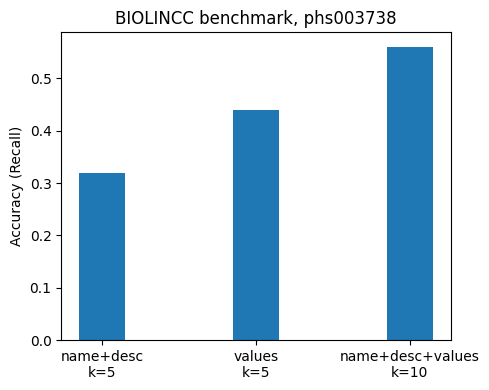

In [488]:
import matplotlib.pyplot as plt

accuracy = [
    float(metrics_per_row_with_numeric_string['is_match_in_top_5_name_desc'].value_counts(normalize=True).loc[True]),
    float(metrics_per_row_with_numeric_string['is_match_in_top_5_numeric_or_string_vals'].value_counts(normalize=True).loc[True]),
    float(metrics_per_row_with_numeric_string['is_match_in_top10_name_desc_val'].value_counts(normalize=True).loc[True])
]
labels = ["name+desc\nk=5", "values\nk=5", "name+desc+values\nk=10"]

plt.figure(figsize=(5,4))
plt.bar(labels, accuracy, width=0.3)
plt.ylabel("Accuracy (Recall)")
plt.title("BIOLINCC benchmark, phs003738")
plt.tight_layout()
plt.savefig('../figs/phs003738_vals.png', dpi=300)

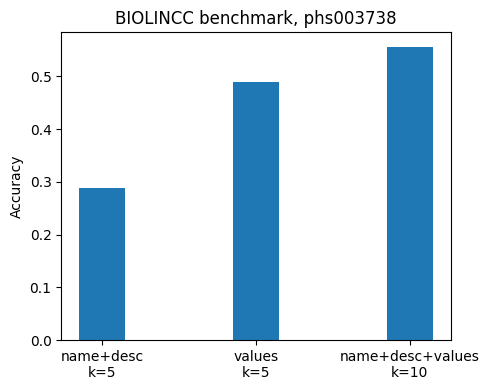

In [489]:
exclude_no_target_values = metrics_per_row_with_numeric_string[metrics_per_row_with_numeric_string['is_target_values'] == 'TRUE']

accuracy = [
    float(exclude_no_target_values['is_match_in_top_5_name_desc'].value_counts(normalize=True).loc[True]),
    float(exclude_no_target_values['is_match_in_top_5_numeric_or_string_vals'].value_counts(normalize=True).loc[True]),
    float(exclude_no_target_values['is_match_in_top10_name_desc_val'].value_counts(normalize=True).loc[True])
]
labels = ["name+desc\nk=5", "values\nk=5", "name+desc+values\nk=10"]

plt.figure(figsize=(5,4))
plt.bar(labels, accuracy, width=0.3)
plt.ylabel("Accuracy")
plt.title("BIOLINCC benchmark, phs003738")
plt.tight_layout()
plt.show()


## TO-DO
- figure out simple encoding of true/false in benchmark
- add custom embedding models